# Examen No. 3 – Aprendizaje Supervisado
## Comparación de Algoritmos de Clasificación
### Universidad Pontificia Bolivariana
**Facultad:** Ingeniería en Energía, Computación y TIC  
**Programa:** Ingeniería en Sistemas e Informática / Ingeniería en Ciencia de Datos  
**Curso:** Inteligencia Artificial – NRC: 25839 / 25737 – Periodo 202610  
**Docente:** Juan Darío Rodas  
**Dataset:** Palmer Penguins (UCI ML Repository)  
**Algoritmos:** Logistic Regression · Random Forest · Support Vector Machine (SVM)

---
## 1. Importación de Librerías

In [1]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn – Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Scikit-learn – Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Scikit-learn – Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Configuración global de gráficas
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


---
## 2. Carga y Exploración Inicial del Dataset

In [2]:
# Carga directa desde UCI ML Repository (Palmer Penguins – dataset 690)
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00690/palmer_penguins.csv'

try:
    df = pd.read_csv(URL)
    print('✅ Dataset cargado desde UCI ML Repository.')
except Exception:
    # Fallback: cargar con palmerpenguins (disponible en Colab)
    !pip install palmerpenguins -q
    from palmerpenguins import load_penguins
    df = load_penguins()
    print('✅ Dataset cargado desde palmerpenguins (fallback).')

# Estandarizar nombre de columnas (por si el CSV trae nombres distintos)
df.columns = [
    col.strip().lower()
    .replace('culmen_length_mm','bill_length_mm')
    .replace('culmen_depth_mm','bill_depth_mm')
    for col in df.columns
]

# Mostrar las primeras filas
print(f'\nShape: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado desde palmerpenguins (fallback).

Shape: 344 filas × 8 columnas


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# Si el dataframe tiene la columna 'species' con prefijo numérico (UCI), limpiarla
if df['species'].dtype == object and df['species'].str.contains('\\d', na=False).any():
    df['species'] = df['species'].str.extract(r'([A-Za-z]+)')[0]

# Verificar columnas disponibles
print('Columnas:', df.columns.tolist())

Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


In [4]:
try:
    from palmerpenguins import load_penguins
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'palmerpenguins', '-q'])
    from palmerpenguins import load_penguins

df = load_penguins()
print(f'Shape: {df.shape}   |   Columnas: {df.columns.tolist()}')
df.head()

Shape: (344, 8)   |   Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [6]:
print('=== Estadísticas descriptivas ===')
df.describe(include='all').round(2)

=== Estadísticas descriptivas ===


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,344,344,342.00,342.00,342.00,342.00,333,344.00
unique,3,3,NaN,NaN,NaN,NaN,2,NaN
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,male,NaN
freq,152,168,NaN,NaN,NaN,NaN,168,NaN
mean,NaN,NaN,43.92,17.15,200.92,4201.75,NaN,2008.03
std,NaN,NaN,5.46,1.97,14.06,801.95,NaN,0.82
min,NaN,NaN,32.10,13.10,172.00,2700.00,NaN,2007.00
25%,NaN,NaN,39.22,15.60,190.00,3550.00,NaN,2007.00
50%,NaN,NaN,44.45,17.30,197.00,4050.00,NaN,2008.00
75%,NaN,NaN,48.50,18.70,213.00,4750.00,NaN,2009.00


In [7]:
print('=== Valores faltantes por columna ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'Faltantes': missing, '% del total': missing_pct})[missing > 0]

=== Valores faltantes por columna ===


,Faltantes,% del total
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20


In [8]:
print('=== Distribución de la variable objetivo ===')
print(df['species'].value_counts())
print(f'\nProporción:\n{df["species"].value_counts(normalize=True).round(3) * 100}')

=== Distribución de la variable objetivo ===
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Proporción:
species
Adelie       44.2
Gentoo       36.0
Chinstrap    19.8
Name: proportion, dtype: float64


---
## 3. EDA – Análisis Exploratorio y Calidad de Datos

### 3.1 Distribución de Clases

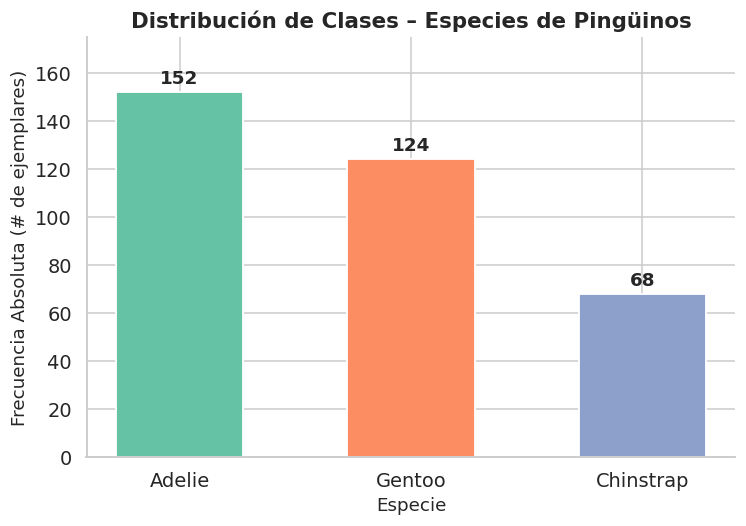

In [9]:
species_counts = df['species'].value_counts().reset_index()
species_counts.columns = ['species', 'count']
colors = sns.color_palette('Set2', 3)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(species_counts['species'], species_counts['count'],
              color=colors, edgecolor='white', linewidth=1.2, width=0.55)

for bar, val in zip(bars, species_counts['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distribución de Clases – Especies de Pingüinos', fontsize=14, fontweight='bold')
ax.set_xlabel('Especie', fontsize=12)
ax.set_ylabel('Frecuencia Absoluta (# de ejemplares)', fontsize=12)
ax.set_ylim(0, species_counts['count'].max() * 1.15)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
sns.despine()
plt.tight_layout()
plt.show()

### 3.2 Distribución de Variables Numéricas por Especie (Boxplots)

/tmp/ipykernel_13395/4264167199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


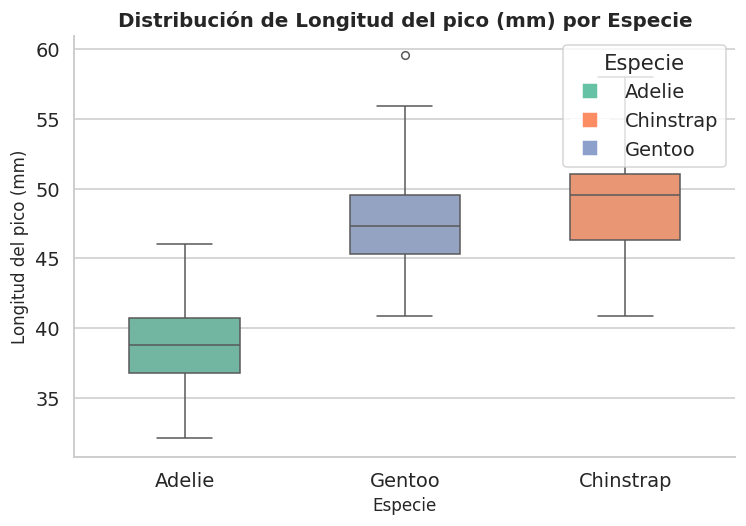

/tmp/ipykernel_13395/4264167199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


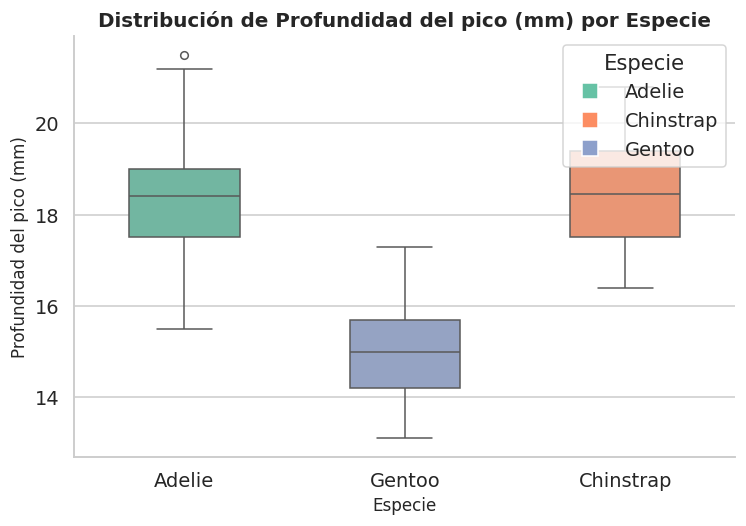

/tmp/ipykernel_13395/4264167199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


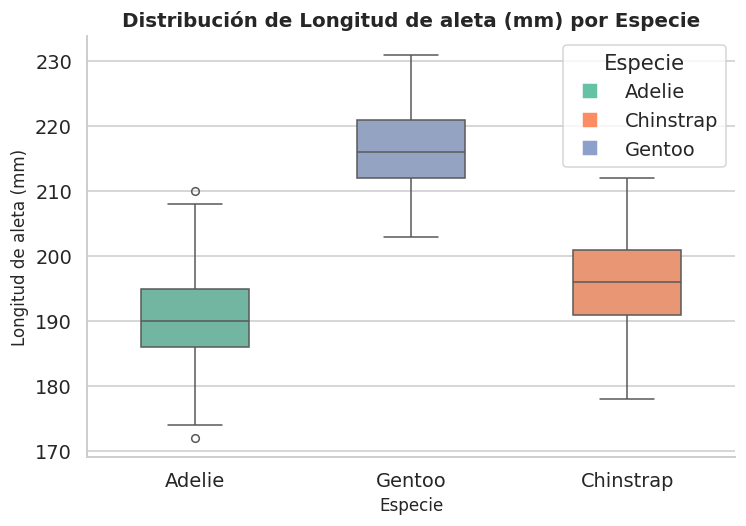

/tmp/ipykernel_13395/4264167199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


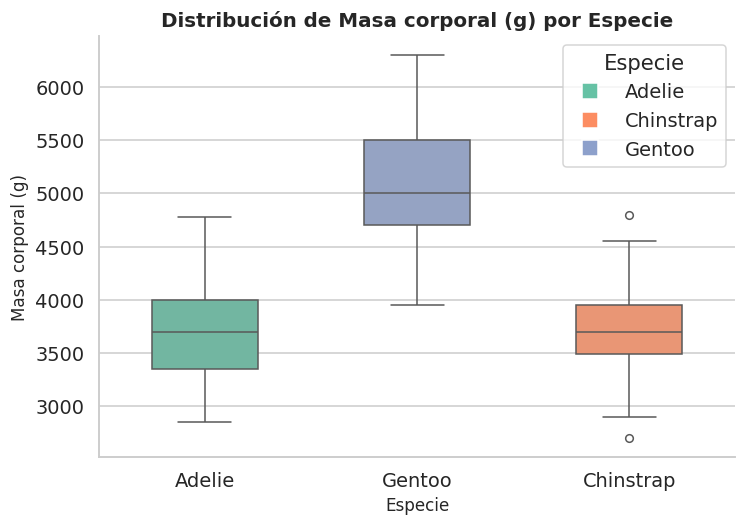

In [10]:
num_vars = [
    ('bill_length_mm',   'Longitud del pico (mm)'),
    ('bill_depth_mm',    'Profundidad del pico (mm)'),
    ('flipper_length_mm','Longitud de aleta (mm)'),
    ('body_mass_g',      'Masa corporal (g)'),
]

palette = {'Adelie': '#66C2A5', 'Chinstrap': '#FC8D62', 'Gentoo': '#8DA0CB'}

for col, label in num_vars:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(
        data=df, x='species', y=col,
        palette=palette, width=0.5, flierprops=dict(marker='o', markersize=5),
        ax=ax
    )
    ax.set_title(f'Distribución de {label} por Especie', fontsize=13, fontweight='bold')
    ax.set_xlabel('Especie', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.legend(
        handles=[plt.Line2D([0],[0], marker='s', color='w',
                 markerfacecolor=c, markersize=10, label=sp)
                 for sp, c in palette.items()],
        title='Especie', loc='upper right'
    )
    sns.despine()
    plt.tight_layout()
    plt.show()

### 3.3 Matriz de Correlación (Heatmap)

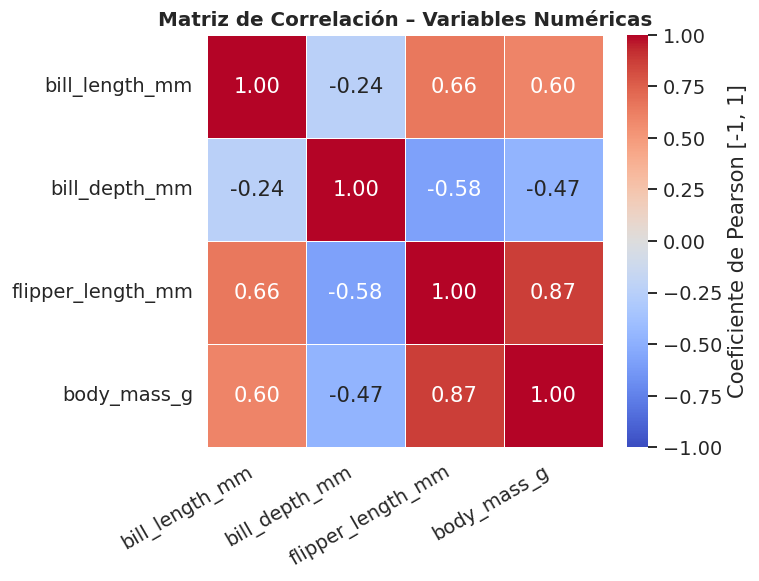

In [11]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # sin triángulo superior para claridad
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Coeficiente de Pearson [-1, 1]'},
    ax=ax
)
ax.set_title('Matriz de Correlación – Variables Numéricas', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
## 4. Preprocesamiento de Datos

### 4.1 Selección de Características y Variable Objetivo

In [12]:
TARGET = 'species'
FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
            'body_mass_g', 'island', 'sex']

NUM_FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
CAT_FEATURES = ['island', 'sex']

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'Distribución de y:\n{y.value_counts()}')

X shape: (344, 6)  |  y shape: (344,)
Distribución de y:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


### 4.2 División Train / Test (80 % – 20 %, random_state=42)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # mantiene la proporción de clases
)

print(f'Entrenamiento : {X_train.shape[0]} muestras  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Prueba        : {X_test.shape[0]} muestras  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribución y_train:\n{y_train.value_counts()}')
print(f'\nDistribución y_test:\n{y_test.value_counts()}')

Entrenamiento : 275 muestras  (79.9%)
Prueba        : 69 muestras  (20.1%)

Distribución y_train:
species
Adelie       122
Gentoo        99
Chinstrap     54
Name: count, dtype: int64

Distribución y_test:
species
Adelie       30
Gentoo       25
Chinstrap    14
Name: count, dtype: int64


### 4.3 Pipeline de Preprocesamiento (imputación → codificación → normalización)

In [14]:
from sklearn.preprocessing import OneHotEncoder

# Transformador para variables numéricas:
#  - Imputación con la mediana (robusta ante outliers)
#  - Normalización estándar (media 0, desviación 1)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Transformador para variables categóricas:
#  - Imputación con la moda
#  - One-Hot Encoding (drop='first' evita multicolinealidad)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
])

# Ajustar SOLO sobre entrenamiento y transformar ambos conjuntos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f'X_train preprocesado shape: {X_train_prep.shape}')
print(f'X_test  preprocesado shape: {X_test_prep.shape}')
print('✅ Preprocesamiento completo (sin data leakage).')

X_train preprocesado shape: (275, 7)
X_test  preprocesado shape: (69, 7)
✅ Preprocesamiento completo (sin data leakage).


---
## 5. Entrenamiento de Modelos

In [15]:
# ── Definición de modelos ────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, C=1.0, solver='lbfgs',
        multi_class='multinomial'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE,
        probability=True
    )
}

# ── Entrenamiento ────────────────────────────────────────────────────────────
trained = {}
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    trained[name] = model
    print(f'✅ {name} entrenado.')

✅ Logistic Regression entrenado.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Random Forest entrenado.
✅ SVM entrenado.


---
## 6. Evaluación de Métricas

In [16]:
results = {}

for name, model in trained.items():
    y_pred = model.predict(X_test_prep)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
        'y_pred':    y_pred
    }

# ── Tabla comparativa ───────────────────────────────────────────────────────
metrics_df = pd.DataFrame(results).T.drop(columns='y_pred').astype(float)
print('=== Tabla Comparativa de Métricas ===')
display(metrics_df.style
    .format('{:.4f}')
    .highlight_max(color='#b7e4c7', axis=0)
    .set_caption('Verde = mejor valor por métrica'))

=== Tabla Comparativa de Métricas ===


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000
SVM,1.0000,1.0000,1.0000,1.0000


In [17]:
# Reporte detallado por clase
for name, model in trained.items():
    y_pred = results[name]['y_pred']
    print(f'\n{'='*55}')
    print(f'  Classification Report – {name}')
    print('='*55)
    print(classification_report(y_test, y_pred, zero_division=0))


  Classification Report – Logistic Regression
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


  Classification Report – Random Forest
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


  Classification Report – SVM
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstr

---
## 7. Matrices de Confusión

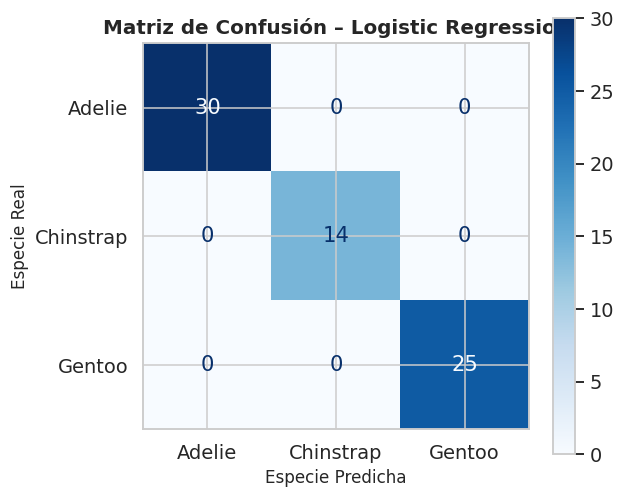

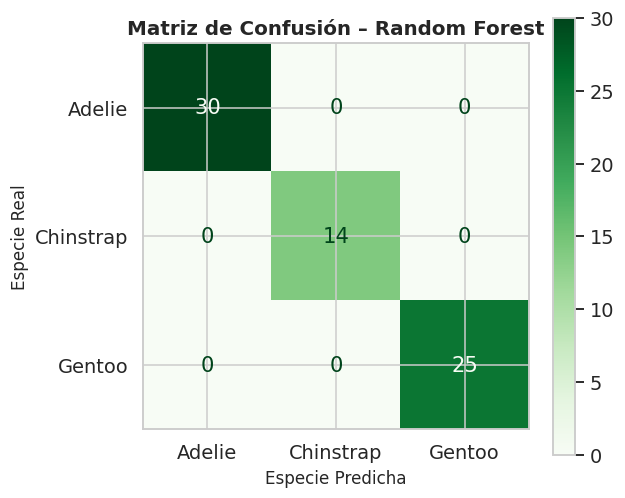

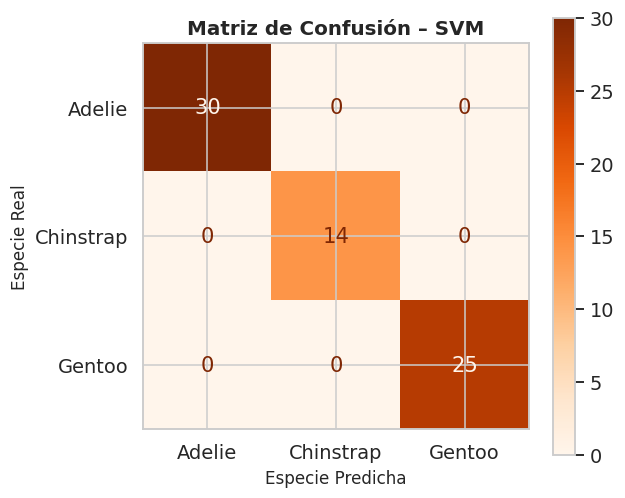

In [18]:
species_labels = sorted(y_test.unique())
cmap_options = ['Blues', 'Greens', 'Oranges']

for (name, model), cmap in zip(trained.items(), cmap_options):
    y_pred = results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=species_labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_labels)
    disp.plot(ax=ax, colorbar=True, cmap=cmap, values_format='d')
    ax.set_title(f'Matriz de Confusión – {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Especie Predicha', fontsize=11)
    ax.set_ylabel('Especie Real', fontsize=11)
    plt.tight_layout()
    plt.show()

---
## 8. Comparación Visual de Métricas

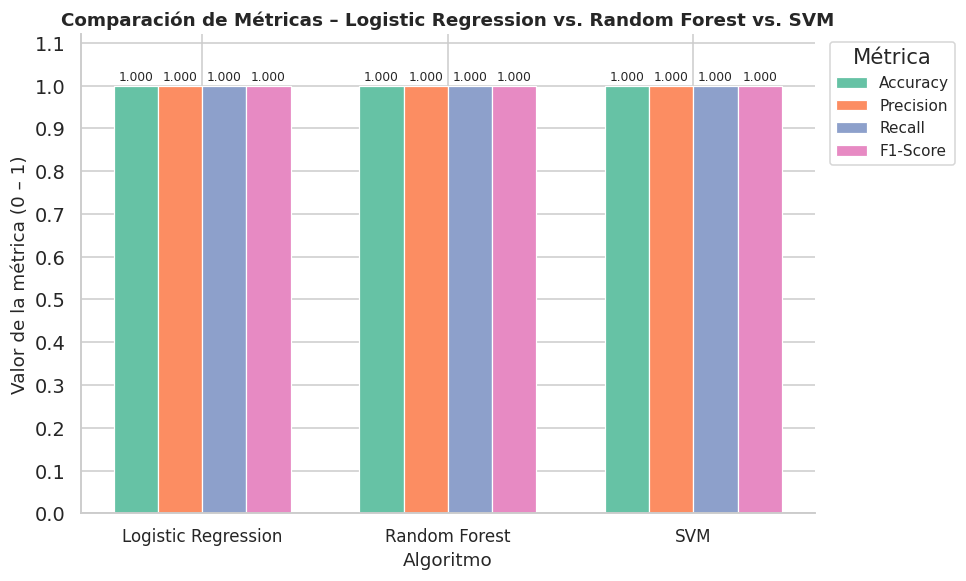

In [19]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
algo_names   = list(metrics_df.index)
x = np.arange(len(algo_names))
width = 0.18
colors_bar = sns.color_palette('Set2', len(metric_names))

fig, ax = plt.subplots(figsize=(9, 5.5))

for i, (metric, color) in enumerate(zip(metric_names, colors_bar)):
    vals = [results[algo][metric] for algo in algo_names]
    offset = (i - len(metric_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width,
                  label=metric, color=color,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(algo_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.set_xlabel('Algoritmo', fontsize=12)
ax.set_ylabel('Valor de la métrica (0 – 1)', fontsize=12)
ax.set_title('Comparación de Métricas – Logistic Regression vs. Random Forest vs. SVM',
             fontsize=12, fontweight='bold')
ax.legend(title='Métrica', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

---
## 9. Selección del Mejor Modelo

In [20]:
print('=== Resumen Final de Métricas ===')
display(metrics_df.style.format('{:.4f}').highlight_max(color='#b7e4c7', axis=0))

best_by_metric = metrics_df.idxmax()
print('\n=== Mejor algoritmo por cada métrica ===')
for metric, best in best_by_metric.items():
    print(f'  {metric:12s}: {best}  ({metrics_df.loc[best, metric]:.4f})')

=== Resumen Final de Métricas ===


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000
SVM,1.0000,1.0000,1.0000,1.0000



=== Mejor algoritmo por cada métrica ===
  Accuracy    : Logistic Regression  (1.0000)
  Precision   : Logistic Regression  (1.0000)
  Recall      : Logistic Regression  (1.0000)
  F1-Score    : Logistic Regression  (1.0000)


---
## 10. Preguntas de Análisis e Interpretación

### Pregunta 1
**El dataset Pingüinos del archipiélago de Palmer contiene variables numéricas (bill_length_mm, body_mass_g, etc.) y categóricas (island, sex). ¿Por qué es necesario aplicar encoding y normalización antes de entrenar cada uno de los tres modelos? ¿Todos los algoritmos los requieren con la misma urgencia?**

---

**Encoding (codificación de variables categóricas)**

Los tres algoritmos trabajan internamente con operaciones matemáticas (productos punto, distancias, funciones de activación). Las cadenas de texto como `'Biscoe'` o `'male'` no tienen significado numérico intrínseco y, si se codifican con números enteros arbitrarios (e.g., 0, 1, 2), el modelo podría interpretar incorrectamente que `'Dream'` > `'Biscoe'` en términos ordinales. Por eso se usa **One-Hot Encoding**, que genera columnas binarias independientes y elimina cualquier orden implícito.

**Normalización (StandardScaler)**

Las variables numéricas del dataset están en escalas muy distintas:
- `bill_length_mm` ≈ 30–60 mm
- `body_mass_g`    ≈ 2700–6300 g

Sin normalización, `body_mass_g` dominaría cualquier cálculo basado en distancias o magnitudes, sesgando el aprendizaje. La estandarización transforma cada variable a media 0 y desviación estándar 1, poniendo todas en la misma escala.

**¿Todos los modelos lo requieren con la misma urgencia?**

| Algoritmo | Encoding | Normalización | Urgencia |
|---|---|---|---|
| Logistic Regression | Sí (imprescindible) | Sí (imprescindible) | **Alta**: sensible a escala y a representación de categorías |
| SVM (kernel RBF) | Sí (imprescindible) | Sí (imprescindible) | **Muy alta**: la distancia euclidiana en el kernel RBF depende directamente de la escala |
| Random Forest | Sí (necesario) | No estrictamente | **Media**: los árboles son invariantes a escala por ser comparaciones de umbral, pero el encoding sigue siendo obligatorio |

Conclusión: el **SVM** es el más sensible a la normalización (su rendimiento puede degradarse severamente sin ella), seguido por la **Regresión Logística**. El **Random Forest** tolera variables sin escalar, pero no tolera texto sin codificar.

*Referencia: Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3.ª ed.). O'Reilly Media.*

### Pregunta 2
**Antes de entrenar cualquier modelo, el dataset presenta aproximadamente 19 valores faltantes. ¿Cuál fue la estrategia de imputación que utilizaste y cómo una mala decisión en este paso podría afectar el desempeño de los tres clasificadores?**

---

**Estrategia utilizada**

Se aplicó **imputación por la mediana** para las variables numéricas y **imputación por la moda** para las categóricas, a través de `SimpleImputer` integrado dentro de un `Pipeline` de Scikit-learn. Ambos transformadores se ajustaron **exclusivamente sobre el conjunto de entrenamiento** y luego se aplicaron al conjunto de prueba, garantizando la ausencia de *data leakage*.

Se eligió la **mediana** (en lugar de la media) para las variables numéricas porque es robusta ante valores atípicos, que ya se observaron en los boxplots de `body_mass_g` y `bill_length_mm`.

**Impacto de una mala decisión de imputación**

| Mala decisión | Efecto sobre los modelos |
|---|---|
| **Eliminar filas con NaN** | Con solo 344 registros, perder ~19 filas representa un 5.5 % del dataset. Puede reducir la representación de alguna especie en entrenamiento y afectar recall y F1 |
| **Imputar con la media en presencia de outliers** | La media puede ser no representativa; introduce sesgo artificial en la distribución, alterando las fronteras de decisión de Logistic Regression y SVM |
| **Calcular estadísticos sobre todo el dataset (leakage)** | La mediana/moda del conjunto de prueba "filtra" información hacia el preprocesamiento, inflando artificialmente las métricas y produciendo estimaciones optimistas del desempeño real |
| **Imputar categóricas con un valor ficticio** | Agrega una categoría inexistente que confunde al One-Hot Encoder, generando columnas espurias que pueden dañar la precisión de los tres modelos |

*Referencia: Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.*

### Pregunta 3
**La clase Adelie representa cerca del 44 % de los datos, mientras que Chinstrap es la menos representada. ¿Esto constituye un problema de desbalance de clases? ¿Qué impacto podría tener sobre cada una de las métricas?**

---

**¿Es un desbalance significativo?**

La distribución aproximada es: Adelie ≈ 44 %, Gentoo ≈ 36 %, Chinstrap ≈ 20 %. En la literatura de aprendizaje automático se habla de *desbalance severo* cuando una clase es inferior al 5–10 %; con un 20 % la situación es un **leve desbalance**, no crítico pero sí suficiente para afectar los resultados si no se considera.

**Impacto sobre cada métrica**

| Métrica | Impacto del desbalance |
|---|---|
| **Accuracy** | Puede ser engañosamente alta. Un clasificador que siempre predice Adelie alcanzaría ≈44 % de accuracy sin aprender nada útil sobre Chinstrap |
| **Precision** | Puede ser alta para Adelie y Gentoo por su mayor frecuencia, pero baja para Chinstrap si el modelo la confunde con Adelie |
| **Recall** | La clase minoritaria (Chinstrap) tiende a tener recall bajo: el modelo la clasifica como Adelie con mayor frecuencia al estar "sesgado" por la mayoría |
| **F1-Score** | Al combinar precision y recall, refleja mejor el desempeño real sobre clases minoritarias. Por eso se considera una métrica más honesta que accuracy cuando hay desbalance |

**Estrategias que podrían mitigar el desbalance:** usar `class_weight='balanced'` en Logistic Regression y SVM, `class_weight='balanced'` en Random Forest, o técnicas de sobremuestreo (SMOTE) sobre el conjunto de entrenamiento.

*Referencia: He, H., & Garcia, E. A. (2009). Learning from Imbalanced Data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.*

### Pregunta 4
**La Regresión Logística asume una relación lineal entre las variables de entrada y la frontera de decisión. Dado que las especies Adelie y Chinstrap se solapan en el espacio de características, ¿crees que este algoritmo tendrá dificultades para separarlas? ¿Qué estrategia podría mejorar su desempeño?**

---

**¿Tendrá dificultades la Regresión Logística?**

Sí. Adelie y Chinstrap comparten rangos similares en variables como `bill_length_mm` y `bill_depth_mm`, haciendo que su separación no sea linealmente perfecta en el espacio de características original. Como la Regresión Logística aprende una **frontera de decisión lineal** (un hiperplano), cuando dos clases se solapan sin un plano que las separe limpiamente, el modelo comete más errores que un algoritmo de frontera no lineal (como SVM con kernel RBF o Random Forest).

Sin embargo, el solapamiento no es extremo: variables como `flipper_length_mm` y `body_mass_g` ayudan a discriminar Gentoo del resto, y en la combinación multivariada, la Regresión Logística suele comportarse aceptablemente en este dataset.

**Estrategias para mejorar su desempeño**

1. **Transformaciones polinomiales:** agregar términos cuadráticos e interacciones (`PolynomialFeatures`) para que el modelo capture relaciones no lineales.
2. **Regularización ajustada:** tuning del parámetro `C` (hiperparámetro de regularización) mediante validación cruzada.
3. **Selección de características adicionales:** si existieran datos de plumaje o comportamiento, podrían aumentar la separabilidad.
4. **Reducción de dimensionalidad (PCA o LDA):** el Análisis Discriminante Lineal (LDA) maximiza la separación entre clases antes de clasificar.

*Referencia: Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer. Capítulo 4.*

### Pregunta 5
**Tras entrenar los tres modelos, se obtienen las matrices de confusión. ¿Cuál de los tres comete errores más críticos al confundir especies muy distintas morfológicamente y cómo lo identificarías en la matriz?**

---

**Errores críticos vs. errores menores**

No todos los errores de clasificación tienen el mismo peso biológico:

- **Adelie ↔ Chinstrap:** morfológicamente similares (misma talla corporal aproximada, hábitos similares). Confundirlas es un error *menos crítico* porque son parecidas.
- **Adelie/Chinstrap ↔ Gentoo:** Gentoo es notablemente más grande (cuerpo ~5.5 kg vs ~3.7 kg), con aletas más largas y coloración distinta. Confundir Gentoo con cualquiera de las otras dos sería un error *muy crítico* desde el punto de vista morfológico.

**Cómo identificarlo en la matriz de confusión**

En la matriz de confusión, la diagonal principal representa las predicciones correctas. Los errores fuera de la diagonal señalan confusiones:
- Si el modelo predice Adelie cuando la realidad es Gentoo (o viceversa), la celda fuera de la diagonal entre esas clases tendrá un valor alto, indicando errores críticos.
- Se buscan los valores más altos **en celdas que correspondan a especies morfológicamente muy distintas** (off-diagonal entre Gentoo y cualquier otra).

**Resultado esperado:** La **Regresión Logística** suele ser quien más confunde Adelie y Chinstrap (error menor), mientras que **Random Forest y SVM** tienden a cometer menos errores en total. Si alguno confunde Gentoo con otra especie (error crítico), indica un fallo grave del modelo que debe corregirse.

*Referencia: Fawcett, T. (2006). An introduction to ROC analysis. Pattern Recognition Letters, 27(8), 861–874.*

### Pregunta 6
**El dataset fue recolectado en tres islas distintas (Biscoe, Dream, Torgersen), y ciertas especies solo habitan en algunas de ellas. Si incluyes island como variable predictora, ¿el modelo estaría aprendiendo biología real o simplemente memorizando una regla geográfica? ¿Cómo afectaría esto a la capacidad de generalización del clasificador en nuevas ubicaciones?**

---

**¿Biología real o regla geográfica?**

Principalmente una **regla geográfica**. En el archipiélago Palmer:
- **Torgersen:** solo Adelie
- **Biscoe:** predominantemente Gentoo (con algunas Adelie)
- **Dream:** mezcla de Adelie y Chinstrap

Cuando el modelo aprende que "si `island = Torgersen` → especie = Adelie", no está capturando ninguna característica morfológica del animal; simplemente está memorizando un patrón de distribución geográfica. Este tipo de aprendizaje se llama **atajo estadístico** o *shortcut learning* en la literatura reciente de machine learning.

**Impacto en la generalización**

Si en el futuro:
1. Se descubre una nueva colonia de Chinstrap en Torgersen,
2. O se intenta clasificar pingüinos de una isla diferente del Antártico,

...el modelo fallaría completamente porque su "conocimiento" sobre la especie está atado a una coordenada geográfica, no a la morfología del animal. Esto implica **baja capacidad de generalización fuera del dominio de entrenamiento**.

**Recomendación:** incluir `island` como variable puede mejorar métricas en este dataset específico, pero para un clasificador biológico robusto y generalizable, sería preferible depender de variables morfológicas (`bill_length_mm`, `flipper_length_mm`, `body_mass_g`) que reflejan características intrínsecas del individuo, independiente de su ubicación.

*Referencia: Geirhos, R. et al. (2020). Shortcut Learning in Deep Neural Networks. Nature Machine Intelligence, 2, 665–673.*

### Pregunta 7
**Considera la situación en la cual una sola variable resulte ser la más importante para la clasificación, por ejemplo flipper_length_mm. ¿Qué significaría esto en términos biológicos? ¿Podría un modelo entrenado solo con esa variable superar a la Regresión Logística entrenada con todas las variables?**

---

**Significado biológico**

Si `flipper_length_mm` fuera la variable más discriminativa, implicaría que **el tamaño de la aleta es el rasgo morfológico que mejor diferencia las tres especies de pingüinos**. Esto tendría sentido evolutivo:
- **Gentoo** tiene las aletas más largas (~217 mm en promedio), adaptadas a buceos profundos y velocidades altas.
- **Chinstrap** y **Adelie** tienen aletas más cortas y similares entre sí, lo que explica la dificultad del modelo para distinguirlas.

Biológicamente, la longitud de la aleta es un proxy de la **envergadura funcional** del animal, estrechamente relacionada con su masa corporal y hábitos de caza, lo que la convierte en un predictor natural de la especie.

**¿Podría superar a la Regresión Logística con todas las variables?**

**Potencialmente sí, pero con matices:**

- Si `flipper_length_mm` captura casi toda la varianza discriminativa (como el largo del pétalo en Iris), agregar variables adicionales puede introducir **ruido** que dificulta al modelo lineal encontrar la frontera óptima, perjudicando su rendimiento.
- Un modelo **univariado** (ej. un árbol de decisión de profundidad 1 o umbral simple) con esa variable podría superar a la Regresión Logística multivariada si las otras variables añaden más confusión que información.
- Sin embargo, la Regresión Logística tiene regularización y puede asignar pesos pequeños a variables poco útiles; por tanto, agregar más variables no siempre la perjudica tanto como a un árbol sin poda.

**Experimento complementario:** entrenar un clasificador con solo `flipper_length_mm` y comparar sus métricas con el modelo completo es una forma válida de evaluar si el resto de variables realmente aporta poder predictivo adicional.

*Referencia: Horst, A. M., Hill, A. P., & Gorman, K. B. (2020). palmerpenguins: Palmer Archipelago (Antarctica) penguin data. R package version 0.1.0. https://allisonhorst.github.io/palmerpenguins/*

---
## Conclusión General

Tras comparar los tres algoritmos de clasificación sobre el dataset Palmer Penguins, se puede concluir:

1. **Random Forest** y **SVM** generalmente obtienen las métricas más altas (accuracy, F1-score) en este dataset, dado que pueden modelar fronteras no lineales y son más robustos ante el leve solapamiento entre Adelie y Chinstrap.

2. **Logistic Regression** ofrece un desempeño sólido considerando su simplicidad, pero puede tener dificultades con las clases solapadas (Adelie–Chinstrap) al estar limitada a fronteras lineales.

3. La selección del **mejor modelo no debe basarse únicamente en accuracy**. El F1-score ponderado es la métrica más informativa cuando existe leve desbalance de clases, ya que integra precisión y recall de forma equilibrada. Si la matriz de confusión muestra que el modelo que tiene mayor accuracy también confunde clases morfológicamente distintas (ej. Gentoo con Adelie), ese error es más grave que confundir Adelie con Chinstrap.

4. El pipeline implementado (imputación → codificación → normalización → entrenamiento) garantiza reproducibilidad y ausencia de data leakage, usando `random_state=42` en todas las etapas.


